# Section 1: Introduction:
In today's competitive business landscape, retaining customers is more crucial than ever. Companies often invest heavily in acquiring new customers, yet the cost of losing an existing customer can be even greater.

Understanding the factors that lead to customer churn—when a customer decides to stop using a service—is essential for creating effective retention strategies. Imagine having the power to predict which customers are at risk of leaving, enabling you to proactively address their needs and concerns before they decide to go.

<center><img src="https://www.cleartouch.in/wp-content/uploads/2022/11/Customer-Churn.png" width=500/></center>

By analyzing a comprehensive dataset that includes customer demographics, account details, and the services they've subscribed to, you can uncover the underlying reasons for churn. This knowledge allows businesses to tailor their retention programs, offering personalized solutions that enhance customer satisfaction and loyalty, ultimately driving long-term growth and profitability. Let's harness the power of data to not only understand why customers leave but to keep them engaged and committed to your brand.

# Section 2: Import the necessary Libraries

In [11]:
# ! pip install imblearn
# ! pip install pandas
# ! pip install seaborn
# ! pip install scikit-learn
! pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)


In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from imblearn.over_sampling import SMOTE

# Section 3: Loading the Data

Download the data [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).

**Dataset Information:**

**Content:**
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called `Churn`.
- ervices that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies.
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents.

In [13]:
# Mounting the drive
# from google.colab import drive
# drive.mount('/content/drive')

In [14]:
# !pip install xlrd openpyxl

In [15]:
# Loading the data
data = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Viewing the data
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
# Remove the column - 'customerID'
data.drop(columns=['customerID'], inplace=True)

In [17]:
# Checking the data information
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

# Section 4: EDA
EDA is the process of analyzing and visualizing the dataset to uncover underlying patterns, trends, and relationships. It helps in understanding the data's structure and guiding the feature selection and modeling process.

## 4.1 Check the distribution of the target variable - `Churn`.


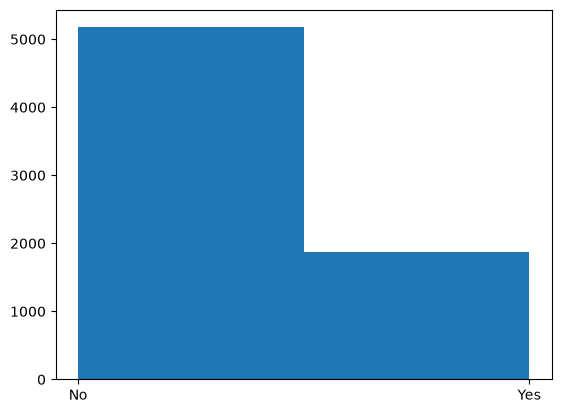

In [18]:
# Check the distribution of the target variable
plt.hist(data['Churn'], bins=2)
plt.show()

## 4.2 Do an analysis of the churn rate wrt all the categorical variables

*Hint: Use normalized values to plot to avoid the class imbalance problem.*

In [19]:
# Analyze churn rate by categorical features
# Listing all the categorical columns
categorical_columns = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

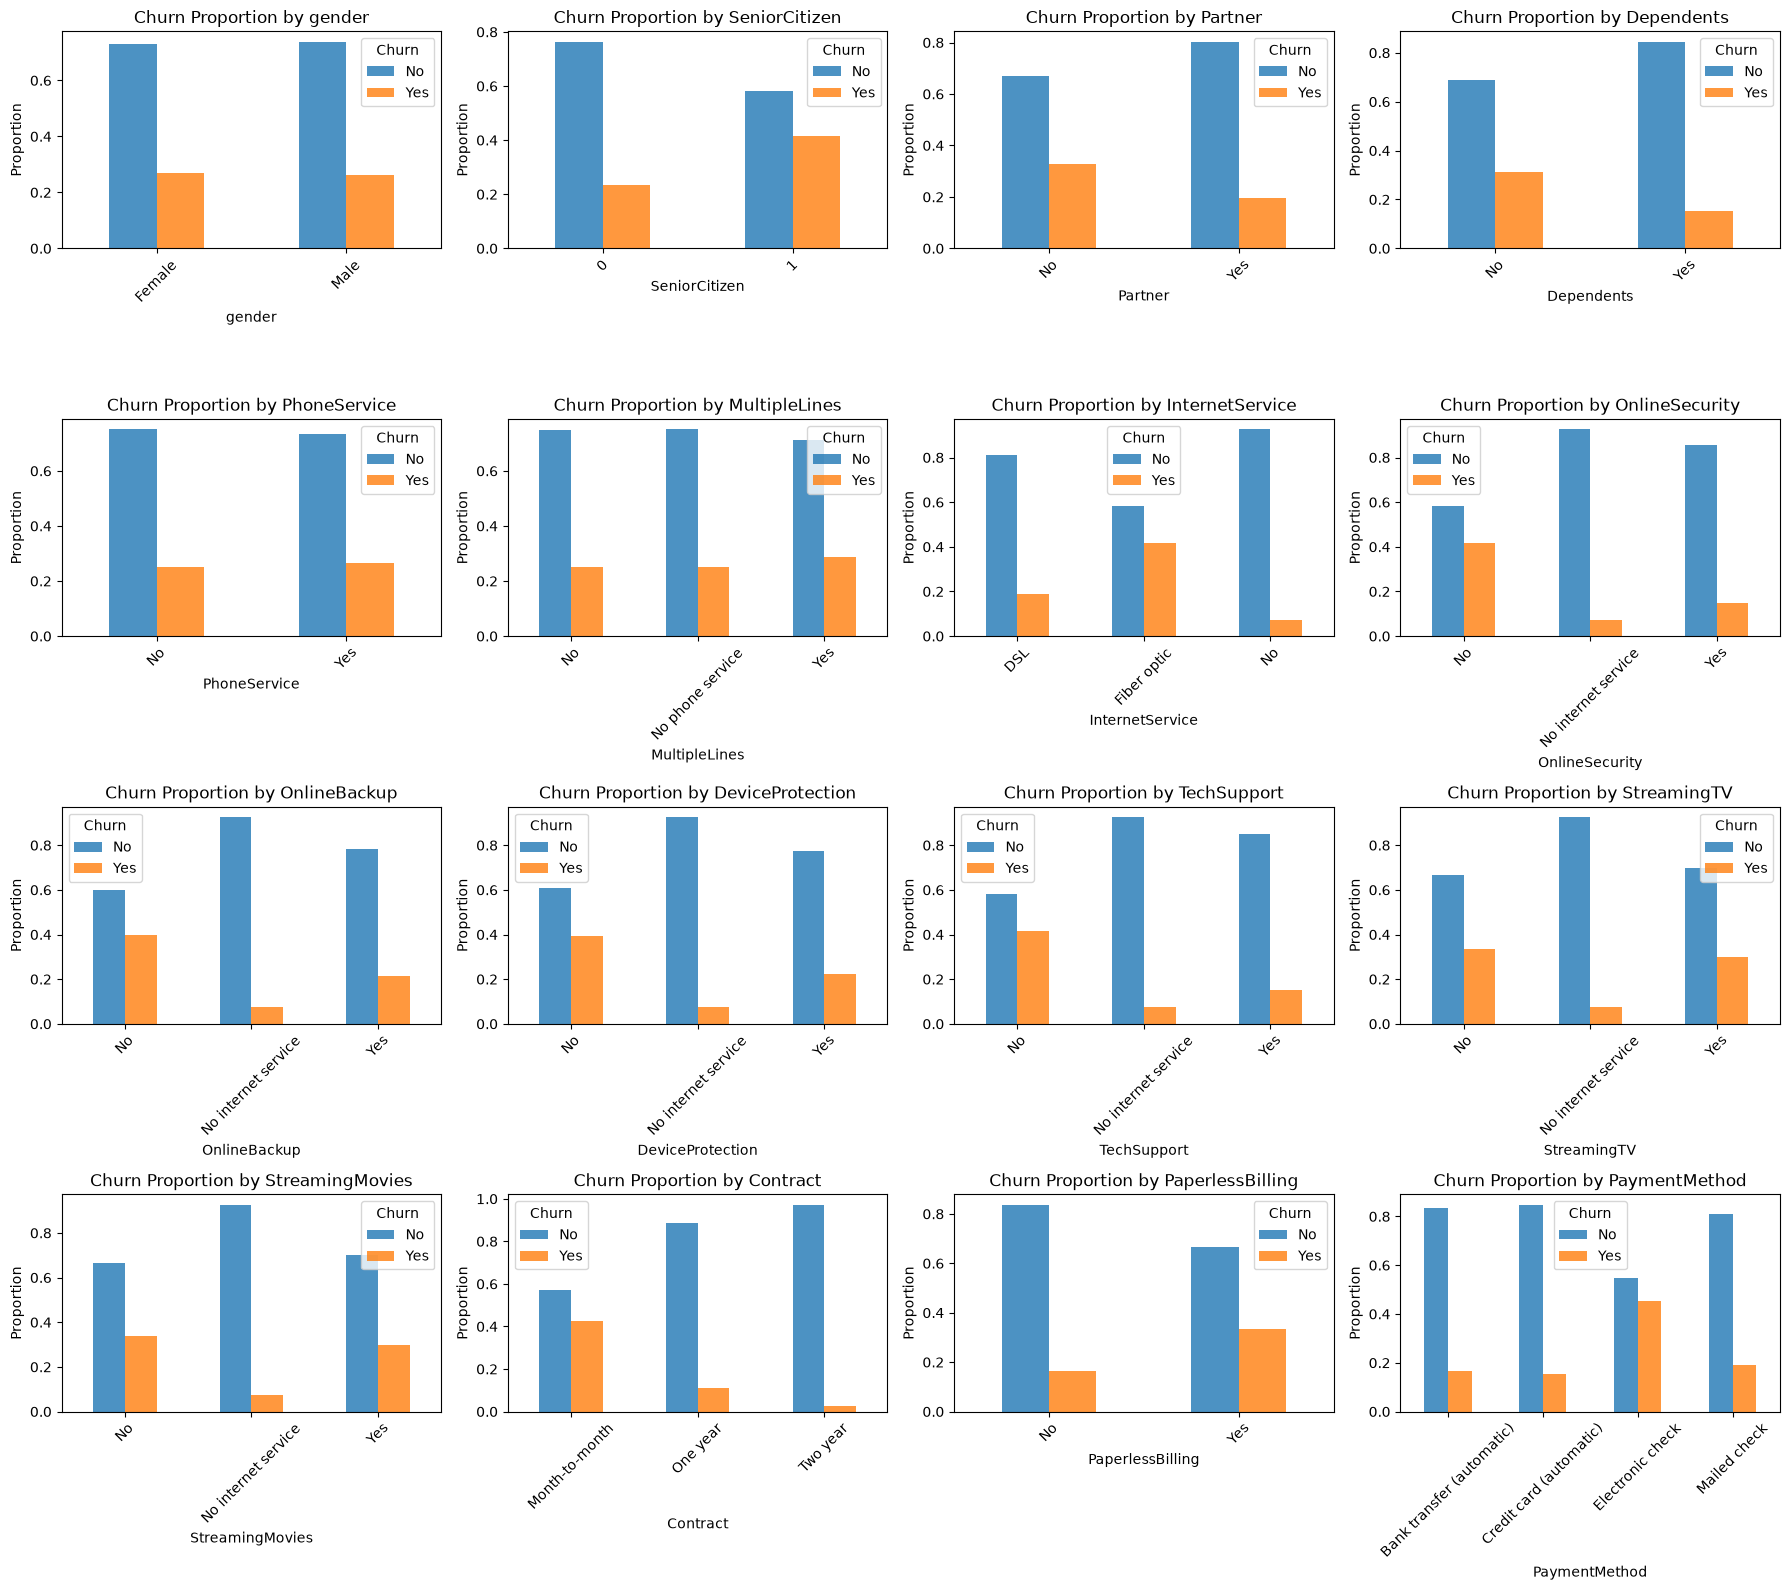

In [20]:
# Visualize the data
# Set up the subplot grid
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18, 16))
axes = axes.flatten()

# Plot each categorical feature in a subplot
for i, column in enumerate(categorical_columns):
    # Calculate normalized proportions because of class imbalance
    normalized_counts = (
        data.groupby(column)['Churn']
        .value_counts(normalize=True)
        .unstack()
    )

    # Plotting the normalized counts as bar plots
    normalized_counts.plot(kind='bar', ax=axes[i], alpha=0.8)   

    # Set title and labels
    axes[i].set_title(f'Churn Proportion by {column}')    
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(column)
    axes[i].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

# Section 5: Feature Engineering

## 5.1 Convert `TotalCharges` column to numeric

In [21]:
# Converting TotalCharges to numeric
data.TotalCharges = pd.to_numeric(data.TotalCharges, errors='coerce')

## 5.2 Handle the categorical features by converting them to dummies

In [22]:
data.select_dtypes(exclude=['object', 'str']).dtypes

SeniorCitizen       int64
tenure              int64
MonthlyCharges    float64
TotalCharges      float64
dtype: object

In [23]:
# One-hot encoding of the categorical features
# column = data.select_dtypes(include=['object']).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'str']).columns.tolist()
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)
# data.select_dtypes(exclude=['object', 'str']).dtypes
data.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


## 5.3 Encode the `Churn` column
- `Yes` as 1
- `No` as 0

In [26]:
# Encode the 'Churn' column
data['Churn'] = data.Churn_Yes.astype(int)


In [27]:
data['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

## 5.4 Do a correlation analysis of the dataset

<Axes: >

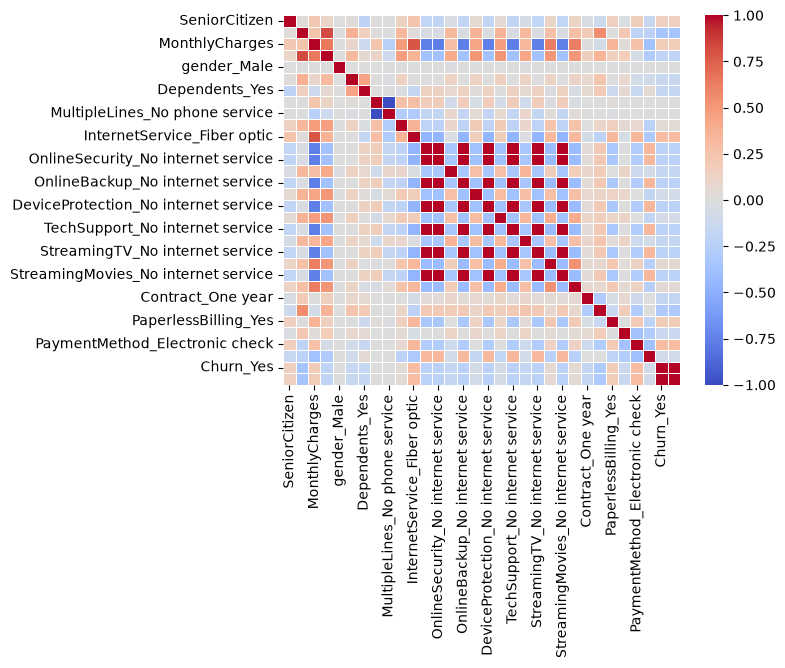

In [28]:
# Create a heatmap displying the correlation coefficients of the variables
corr = data.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)

## 5.5 Check for null values & handle them

In [29]:
# Checking the null values
data.isnull().sum()

SeniorCitizen                             0
tenure                                    0
MonthlyCharges                            0
TotalCharges                             11
gender_Male                               0
Partner_Yes                               0
Dependents_Yes                            0
PhoneService_Yes                          0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service           0
StreamingTV_Yes                           0
StreamingMovies_No internet serv

In [72]:
# Imputing with the mean
# Calculating the mean of the data
mean = data.TotalCharges.mean()
# Impute the mean
data.TotalCharges = data.TotalCharges.fillna(mean)

# Check the data
data.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,Churn
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,True,False,True,False,False,0
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,0
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,True,False,False,True,True,1
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,0
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,True,False,True,False,True,1


In [73]:
data.isnull().sum()

SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

# Section 6: Model Building

## 6.1 Split the data into train and test

In [74]:
from sklearn.model_selection import train_test_split

In [ ]:
data.drop

In [95]:

# Define a function to split the data
def split_data(df: pd.DataFrame, target: str, test_size: float):
    # Create features and target
    X = df.drop(columns=[target, 'Churn_Yes'])
    y = df[target]

    # Split into train & test
    train_x, test_x, train_y, test_y = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=42
    )

    return train_x, test_x, train_y, test_y

In [96]:
# Call the function to split the data
train_x, test_x, train_y, test_y = split_data(data, target='Churn', test_size=0.2)

In [97]:
# Check the data
print("Training data shape:", train_x.shape, train_y.shape, test_x.shape, test_y.shape)

Training data shape: (5634, 30) (5634,) (1409, 30) (1409,)


## 6.2 Scale the data

In [98]:
from sklearn.preprocessing import StandardScaler

In [99]:
# Scaling the data
stdscaler = StandardScaler()
x_train = stdscaler.fit_transform(train_x)
x_test = stdscaler.fit_transform(test_x)

## 6.3 Build the Logistic Regression Model & check the metrics

In [100]:
from sklearn.linear_model import LogisticRegression

In [121]:
# Building the logistic regression model
lr = LogisticRegression(random_state=42, max_iter=2000)
lr.fit(x_train, train_y)
# Make predictions
train_pred = lr.predict(x_train)
test_pred = lr.predict(x_test)


In [122]:
lr.coef_

array([[ 0.05827523, -1.31032565, -0.6288534 ,  0.60905652, -0.02562178,
         0.02735272, -0.07494252, -0.03421718,  0.03421718,  0.16911904,
         0.62472427, -0.07564662, -0.07564662, -0.15757438, -0.07564662,
        -0.04382094, -0.07564662,  0.02896115, -0.07564662, -0.11968259,
        -0.07564662,  0.18086614, -0.07564662,  0.23137552, -0.26911899,
        -0.61908134,  0.16350009, -0.03628875,  0.1513347 , -0.01314707]])

In [123]:
print('Accuracy: {:.4f}'.format(accuracy_score(test_y, test_pred)))
print('Precision: {:.4f}'.format(precision_score(test_y, test_pred)))
print('Recall: {:.4f}'.format(recall_score(test_y, test_pred)))
print('F1 Score: {:.4f}'.format(f1_score(test_y, test_pred)))
print('Classification Report:')


Accuracy: 0.8204
Precision: 0.6840
Recall: 0.5979
F1 Score: 0.6381
Classification Report:


In [124]:
# Print the classification report
print(classification_report(train_y, train_pred))
print(classification_report(test_y, test_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      4138
           1       0.66      0.54      0.59      1496

    accuracy                           0.80      5634
   macro avg       0.75      0.72      0.73      5634
weighted avg       0.79      0.80      0.80      5634

              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409



## 6.4 Build a KNN model & Check the metrics

In [110]:
from sklearn.neighbors import KNeighborsClassifier

In [118]:
# Initialize the KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Fit the model
knn.fit(x_train, train_y)

# Make predictions
test_pred = knn.predict(x_test)


# Evaluation of the model
print('Accuracy: {:.4f}'.format(accuracy_score(test_y, test_pred)))
print('Precision: {:.4f}'.format(precision_score(test_y, test_pred)))
print('Recall: {:.4f}'.format(recall_score(test_y, test_pred)))
print('F1 Score: {:.4f}'.format(f1_score(test_y, test_pred)))
print('Classification Report:')
print(classification_report(test_y, test_pred))

Accuracy: 0.7729
Precision: 0.5836
Recall: 0.4960
F1 Score: 0.5362
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1036
           1       0.58      0.50      0.54       373

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409



## 6.5 Handle the class imbalance  & check the metrics

In [ ]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(train_x, train_y)

# Initialize the Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)

# Fit the model on the smoted data
lr.fit(x_train_smote, y_train_smote)

# Predict on the testing set
test_pred_lr = lr.predict(test_x)

# Print the classification report
print('Accuracy: {:.4f}'.format(accuracy_score(test_y, test_pred_lr)))
print('Precision: {:.4f}'.format(precision_score(test_y, test_pred_lr)))
print('Recall: {:.4f}'.format(recall_score(test_y, test_pred_lr)))
print('F1 Score: {:.4f}'.format(f1_score(test_y, test_pred_lr)))
print('Classification Report:')
print(classification_report(test_y, test_pred_lr))

In [ ]:
# Initialize the KNN model


# Fit the model on smoted data


# Make predictions


# Evaluation of the model
